# Powder Average of Affinely Stretched Random-Line Spectra

This notebook assigns a radial $k$ distribution, computes the corresponding isotropic random-line scattering spectrum, and then applies an affine stretch. The default is the positive-truncated `gaussian_radial` distribution. For the real-space convention $r'=F r$, a scalar spectrum transforms as $I_F(Q)=A_F I_0(|F^T Q|)$. The powder average is evaluated by angular quadrature and by a centered log-stretch series.

With $B=F F^T$ and $Q=Q n$, the exact reduction is $\bar I_F(Q)=A_F(4\pi)^{-1}\int_{S^2}I_0(Q\sqrt{n^T B n})d\Omega$. Only the principal stretches matter. For a uniaxial stretch it reduces to $A_F\int_0^1 I_0(Q\sqrt{\lambda_\perp^2+(\lambda_\parallel^2-\lambda_\perp^2)\mu^2})d\mu$. An arbitrary tabulated $I_0$ generally has no simpler closed form.


M_J direct_12d: 150/3001 r values (1.3s)
M_J direct_12d: 300/3001 r values (2.6s)
M_J direct_12d: 450/3001 r values (3.9s)
M_J direct_12d: 600/3001 r values (5.2s)
M_J direct_12d: 750/3001 r values (6.5s)
M_J direct_12d: 900/3001 r values (7.8s)
M_J direct_12d: 1050/3001 r values (9.1s)
M_J direct_12d: 1200/3001 r values (10.4s)
M_J direct_12d: 1350/3001 r values (11.6s)
M_J direct_12d: 1500/3001 r values (12.9s)
M_J direct_12d: 1650/3001 r values (14.3s)
M_J direct_12d: 1800/3001 r values (15.7s)
M_J direct_12d: 1950/3001 r values (16.9s)
M_J direct_12d: 2100/3001 r values (18.3s)
M_J direct_12d: 2250/3001 r values (19.5s)
M_J direct_12d: 2400/3001 r values (20.8s)
M_J direct_12d: 2550/3001 r values (22.2s)
M_J direct_12d: 2700/3001 r values (23.5s)
M_J direct_12d: 2850/3001 r values (24.8s)
M_J direct_12d: 3000/3001 r values (26.1s)
M_J direct_12d: 3001/3001 r values (26.1s)
distribution=gaussian_radial; sampling=quadrature
<k>=1; std(k)=0.15994892; k_eff=1.012711; rho0=0.10881781
hi

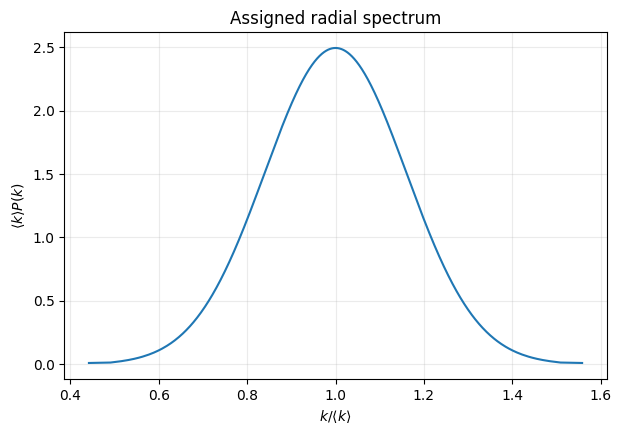

In [1]:
%matplotlib inline
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.special import erf, erfi
from scipy.interpolate import UnivariateSpline
import rw_line_scattering as rls
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.25})

# Radial-spectrum assignment.
k_distribution = "gaussian_radial"
k0_nominal = 1.0
k_distribution_params = {"r_sigma_k": 0.16}
r_sigma_k = k_distribution_params["r_sigma_k"]
k_sampling = "quadrature"  # deterministic radial nodes and weights
num_modes_k = 2**11
random_seed = 12345

# Isotropic line-scattering accuracy controls.
N_samp_U = 2**16
r_min_factor = 1e-3
r_max_factor = 250.0
r_split_factor = 5.0
Nr = 3000
Nr_small = 600
NQ = 260

line_result = rls.compute_uniform_line_scattering(
    k0_nominal=k0_nominal,
    r_sigma_k=r_sigma_k,
    k_distribution_params=k_distribution_params,
    k_distribution=k_distribution,
    k_sampling=k_sampling,
    num_modes_k=num_modes_k,
    random_seed=random_seed,
    Nr=Nr, Nr_small=Nr_small, NQ=NQ,
    r_min_factor=r_min_factor,
    r_max_factor=r_max_factor,
    r_grid_mode="mixed",
    r_split_factor=r_split_factor,
    Q_min_factor=0.1, Q_max_factor=20,
    N_samp_U=N_samp_U,
    jacobian_method="direct_12d",
    use_asymptotic=True,
    progress=True,
)
Q_input = np.asarray(line_result.Q_grid, float)
I_input = np.asarray(line_result.I_L, float)
k_radii = np.asarray(line_result.k_radii, float)
k_weights = np.asarray(line_result.k_weights, float)
k_mean = float(np.dot(k_weights, k_radii))
k_std = float(np.sqrt(np.dot(k_weights, (k_radii-k_mean)**2)))
k_eff = float(np.sqrt(line_result.mu2))
rho0 = float(line_result.rho0)
high_q = (Q_input/k_eff >= 5.0) & (Q_input/k_eff <= 30.0)
line_tail = float(np.median(Q_input[high_q]*I_input[high_q]))
print(f"distribution={k_distribution}; sampling={k_sampling}")
print(f"<k>={k_mean:.8g}; std(k)={k_std:.8g}; k_eff={k_eff:.8g}; rho0={rho0:.8g}")
print(f"high-Q check: median Q I={line_tail:.8g}; pi rho0={np.pi*rho0:.8g}")
fig, ax = plt.subplots()
density = k_weights/np.maximum(np.gradient(k_radii), np.finfo(float).tiny)
ax.plot(k_radii/k_mean, density*k_mean)
ax.set(xlabel=r"$k/\langle k\rangle$", ylabel=r"$\langle k\rangle P(k)$", title="Assigned radial spectrum")
plt.show()


## Powder-average functions

The general function uses a product Gauss-Legendre/periodic angular rule. The uniaxial function uses the exact one-dimensional reduction. Logarithmic interpolation is used only for the $Q$ coordinate; intensity itself is interpolated linearly so signed numerical values remain valid.


In [2]:
def principal_stretches(F):
    F = np.asarray(F, float)
    if F.shape != (3, 3) or not np.all(np.isfinite(F)) or np.linalg.det(F) <= 0:
        raise ValueError("F must be a finite orientation-preserving 3x3 tensor")
    return np.linalg.svd(F, compute_uv=False)

def input_intensity(Q):
    Q = np.asarray(Q, float)
    if np.any(Q < Q_input[0]) or np.any(Q > Q_input[-1]):
        raise ValueError("stretched Q arguments leave the input data range")
    return np.interp(np.log(Q), np.log(Q_input), I_input)

def powder_average(Q, F, intensity=input_intensity, amplitude=1.0, n_mu=96, n_phi=128):
    Q = np.asarray(Q, float)
    lam = principal_stretches(F)
    mu, wm = leggauss(n_mu)
    phi = 2*np.pi*(np.arange(n_phi)+0.5)/n_phi
    s = np.sqrt(np.maximum(0.0, 1-mu**2))
    nx = s[:, None]*np.cos(phi)[None, :]
    ny = s[:, None]*np.sin(phi)[None, :]
    nz = np.broadcast_to(mu[:, None], nx.shape)
    scale = np.sqrt((lam[0]*nx)**2+(lam[1]*ny)**2+(lam[2]*nz)**2)
    values = intensity(Q[:, None, None]*scale[None, :, :])
    return float(amplitude)*np.sum(values*wm[None, :, None], axis=(1, 2))/(2*n_phi)

def powder_average_uniaxial(Q, lambda_perp, lambda_parallel, intensity=input_intensity, amplitude=1.0, n_mu=192):
    mu, w = leggauss(n_mu)
    scale = np.sqrt(lambda_perp**2+(lambda_parallel**2-lambda_perp**2)*mu**2)
    values = intensity(np.asarray(Q)[:, None]*scale[None, :])
    return float(amplitude)*0.5*np.sum(values*w[None, :], axis=1)


## Incompressible uniaxial example

Here $\lambda_\parallel=\lambda$ and $\lambda_\perp=\lambda^{-1/2}$, so $\det F=1$. Set `amplitude_mode='shape'` to compare spectral shapes. For an advected conserved scalar density, the usual per-current-volume convention gives `A_F=det(F)`.


principal stretches: [1.2        0.91287093 0.91287093]
det(F)=1; identity-stretch error=2.478e-16
general/uniaxial normalized max difference=2.649e-06
uniaxial quadrature n_mu= 24: normalized max error=7.382e-05
uniaxial quadrature n_mu= 48: normalized max error=1.421e-05
uniaxial quadrature n_mu= 96: normalized max error=8.514e-06
uniaxial quadrature n_mu=192: normalized max error=2.246e-06


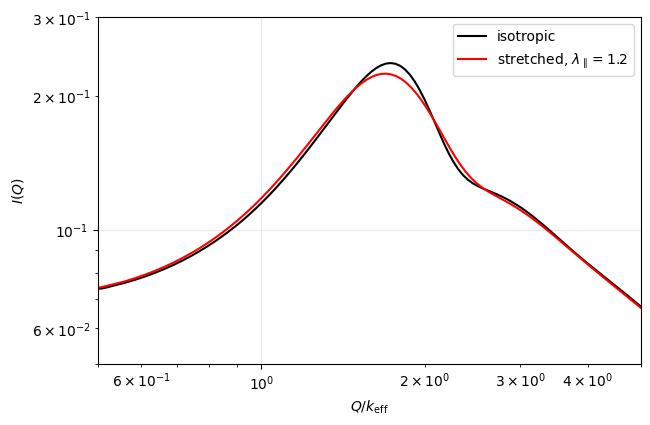

In [11]:
stretch_ratio = 1.2
lambda_parallel = stretch_ratio
lambda_perp = stretch_ratio**(-0.5)
F = np.diag([lambda_perp, lambda_perp, lambda_parallel])
amplitude_mode = "shape"
A_F = 1.0 if amplitude_mode == "shape" else np.linalg.det(F)
lam = principal_stretches(F)
Q_powder = np.geomspace(Q_input[0]/np.min(lam), Q_input[-1]/np.max(lam), 240)
I_powder = powder_average_uniaxial(Q_powder, lambda_perp, lambda_parallel, amplitude=A_F, n_mu=192)
I_reference = powder_average_uniaxial(Q_powder, lambda_perp, lambda_parallel, amplitude=A_F, n_mu=512)
I_check = powder_average(Q_powder, F, amplitude=A_F)
error_scale = max(float(np.max(np.abs(I_reference))), 1e-14)
rel = np.max(np.abs(I_check-I_reference))/error_scale
I_identity = powder_average(Q_powder, np.eye(3), amplitude=1.0)
identity_error = np.max(np.abs(I_identity-input_intensity(Q_powder)))/error_scale
print("principal stretches:", lam)
print(f"det(F)={np.linalg.det(F):.8g}; identity-stretch error={identity_error:.3e}")
print(f"general/uniaxial normalized max difference={rel:.3e}")
for n_mu_test in (24, 48, 96, 192):
    trial = powder_average_uniaxial(Q_powder, lambda_perp, lambda_parallel, amplitude=A_F, n_mu=n_mu_test)
    err = np.max(np.abs(trial-I_reference))/error_scale
    print(f"uniaxial quadrature n_mu={n_mu_test:3d}: normalized max error={err:.3e}")
fig, ax = plt.subplots()
ax.loglog(Q_input/k_eff, I_input, label="isotropic", linewidth=1.5, color="black")
ax.loglog(Q_powder/k_eff, I_powder, label=fr"stretched, $\lambda_\parallel={stretch_ratio:g}$", linewidth=1.5, color="red")
ax.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$I(Q)$")
ax.set_xlim(0.5, 5)
ax.set_ylim(0.05,0.3)
ax.legend()
plt.show()


## Closed-form Gaussian check

For the special input $I_0(Q)=e^{-aQ^2}$ the uniaxial integral is closed-form. Put $c=aQ^2(\lambda_\parallel^2-\lambda_\perp^2)$. The angular factor is $\sqrt{\pi}\,erf(\sqrt c)/(2\sqrt c)$ for $c>0$, one for $c=0$, and $\sqrt{\pi}\,erfi(\sqrt{-c})/(2\sqrt{-c})$ for $c<0$. This validates the quadrature; the random-line scattering curve is not Gaussian and uses the integral above.


In [4]:
def gaussian_closed(Q, a, lp, lz):
    Q = np.asarray(Q, float)
    c = a*Q**2*(lz**2-lp**2)
    f = np.ones_like(c)
    pos, neg = c > 1e-12, c < -1e-12
    f[pos] = np.sqrt(np.pi)*erf(np.sqrt(c[pos]))/(2*np.sqrt(c[pos]))
    f[neg] = np.sqrt(np.pi)*erfi(np.sqrt(-c[neg]))/(2*np.sqrt(-c[neg]))
    return np.exp(-a*Q**2*lp**2)*f

Qt = np.geomspace(1e-3, 3, 120)
a = 0.7
gaussian = lambda q: np.exp(-a*np.asarray(q)**2)
num = powder_average_uniaxial(Qt, lambda_perp, lambda_parallel, intensity=gaussian)
exact = gaussian_closed(Qt, a, lambda_perp, lambda_parallel)
print(f"closed-form Gaussian check: max abs error={np.max(np.abs(num-exact)):.3e}")


closed-form Gaussian check: max abs error=1.499e-15


## Log-stretch series expansion

Even when the angular integral has no closed form, it has a systematic series. Define the directional log-stretch $\delta(n)=\tfrac12\log(n^TFF^Tn)$ and $D=Q\,d/dQ=d/d\log Q$. Then $I_0(Qe^{\delta})=\sum_{m=0}^{\infty}\delta^m D^mI_0(Q)/m!$.

For better convergence we center the expansion at $\delta_0=\langle\delta\rangle_\Omega$. With $q_*=Qe^{\delta_0}$ and central moments $M_m=\langle(\delta-\delta_0)^m\rangle_\Omega$, the powder spectrum is $A_F\sum_m M_m D^mI_0(q_*)/m!$. Here $M_0=1$ and $M_1=0$, so the leading anisotropic correction is second order. The angular moments depend only on the stretch tensor and are calculated once. Since high derivatives amplify Monte Carlo and transform noise in the input curve, a weak smoothing spline in $\log Q$ is used. The implementation supports orders zero through three.


order 0: normalized RMS error=1.174e-02
order 1: normalized RMS error=1.174e-02
order 2: normalized RMS error=2.607e-03
order 3: normalized RMS error=2.339e-03
mean log-stretch delta0=0.010195012; central moments=[1.00000000e+00 0.00000000e+00 7.10968577e-03 2.76529755e-04]


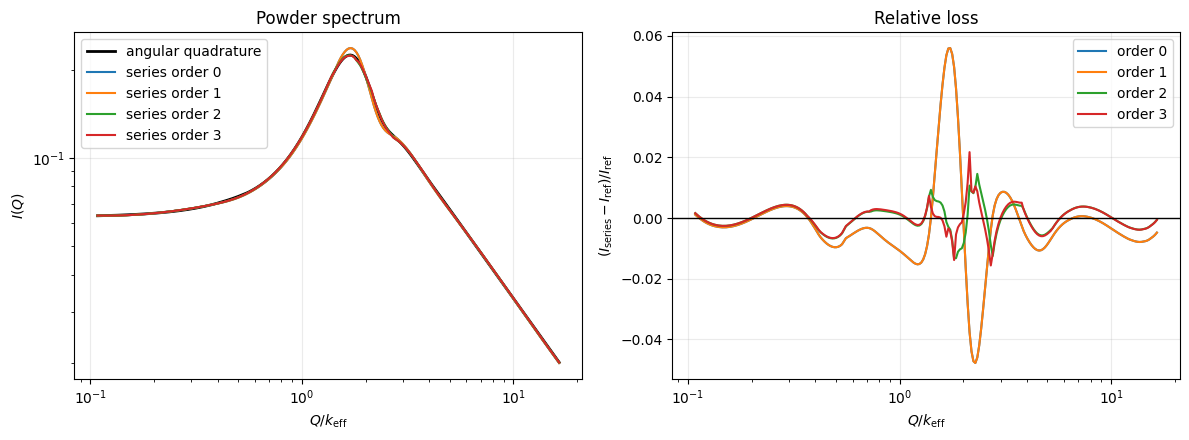

In [8]:
def log_stretch_moments(F, max_order=3, n_mu=160, n_phi=256):
    if not 0 <= max_order <= 3:
        raise ValueError("the cubic-spline implementation supports orders 0 through 3")
    lam = principal_stretches(F)
    mu, wm = leggauss(n_mu)
    phi = 2*np.pi*(np.arange(n_phi)+0.5)/n_phi
    s = np.sqrt(np.maximum(0.0, 1-mu**2))
    nx = s[:, None]*np.cos(phi)[None, :]
    ny = s[:, None]*np.sin(phi)[None, :]
    nz = np.broadcast_to(mu[:, None], nx.shape)
    delta = 0.5*np.log((lam[0]*nx)**2+(lam[1]*ny)**2+(lam[2]*nz)**2)
    average = lambda x: np.sum(x*wm[:, None])/(2*n_phi)
    delta0 = float(average(delta))
    centered = delta-delta0
    moments = np.array([1.0]+[average(centered**m) for m in range(1, max_order+1)])
    return delta0, moments

def powder_average_series(Q, F, order=3, amplitude=1.0, smoothing_fraction=1e-4):
    delta0, moments = log_stretch_moments(F, max_order=order)
    smoothing = float(smoothing_fraction)*len(I_input)*np.var(I_input)
    spline = UnivariateSpline(np.log(Q_input), I_input, k=3, s=smoothing)
    x_star = np.log(np.asarray(Q, float))+delta0
    if np.any(x_star < np.log(Q_input[0])) or np.any(x_star > np.log(Q_input[-1])):
        raise ValueError("series expansion point leaves the input data range")
    result = np.zeros_like(x_star)
    for m in range(order+1):
        result += moments[m]*spline(x_star, nu=m)/math.factorial(m)
    return float(amplitude)*result, delta0, moments

series_curves = {}
for order in range(4):
    curve, delta0, moments = powder_average_series(Q_powder, F, order=order, amplitude=A_F)
    series_curves[order] = curve
    scale = np.maximum(np.max(np.abs(I_powder)), 1e-14)
    rms = np.sqrt(np.mean((curve-I_powder)**2))/scale
    print(f"order {order}: normalized RMS error={rms:.3e}")
print(f"mean log-stretch delta0={delta0:.8g}; central moments={moments}")

fig, (ax, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax.loglog(Q_powder/k_eff, I_reference, color="black", lw=2, label="angular quadrature")
relative_floor = 1e-8*np.max(np.abs(I_reference))
reliable = np.abs(I_reference) > relative_floor
for order, curve in series_curves.items():
    line, = ax.loglog(Q_powder/k_eff, np.abs(curve), label=f"series order {order}")
    relative_loss = np.full_like(curve, np.nan)
    relative_loss[reliable] = (curve[reliable]-I_reference[reliable])/I_reference[reliable]
    ax_loss.semilogx(Q_powder/k_eff, relative_loss, color=line.get_color(), label=f"order {order}")
ax.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$I(Q)$", title="Powder spectrum")
ax_loss.axhline(0.0, color="black", lw=1)
ax_loss.set(xlabel=r"$Q/k_{\rm eff}$", ylabel=r"$(I_{\rm series}-I_{\rm ref})/I_{\rm ref}$", title="Relative loss")
ax.legend()
ax_loss.legend()
fig.tight_layout()
plt.show()


## Scope limitation

The calculation is exact for the affine scalar-spectrum model $I_F(Q)=A_F I_0(|F^TQ|)$. A materially stretched line measure can additionally weight a segment with tangent $t$ by $|Ft|$. That tangent-dependent factor cannot generally be recovered from the isotropic powder curve $I_0(Q)$ alone; it requires a tangent-resolved line correlation or a new Kac-Rice calculation.


In [6]:
output_dir = Path("rw_line_aniso_output")
output_dir.mkdir(exist_ok=True)
np.savez(output_dir/"aniso_powder_data.npz", Q_input=Q_input, I_input=I_input, k_radii=k_radii, k_weights=k_weights, r_grid=line_result.r_grid, C_L=line_result.C_L, Q=Q_powder, I_powder=I_powder, I_reference=I_reference, I_series_order0=series_curves[0], I_series_order1=series_curves[1], I_series_order2=series_curves[2], I_series_order3=series_curves[3], F=F, principal_stretches=lam, amplitude_factor=A_F, stretch_ratio=stretch_ratio, lambda_perp=lambda_perp, lambda_parallel=lambda_parallel, k0_nominal=k0_nominal, r_sigma_k=r_sigma_k, k_eff=k_eff, rho0=rho0)
print(f"saved data to {output_dir.resolve()}")


saved data to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\rw_line_aniso_output
